# Retail Sales — Exploratory Data Analysis

**Track:** Data Analytics | **OIB-SIP:** Level 1 — Task 1  
**Author:** David Eléazar ADJA

## Objective
Explore retail transactions to identify time trends, customer demographics, category performance, and actionable business insights.

> Dataset source and attribution: `../data/SOURCE.md`. This is a small, synthetic-looking educational dataset; findings are descriptive and should not be generalized to a real retailer without validation.

## Questions
1. How does revenue change over months and quarters?
2. Which product categories contribute most to sales?
3. What do customer age and gender distributions look like?
4. Which numerical variables are associated with transaction value?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 5)
DATA_PATH = Path('../data/retail_sales_dataset.csv')
df = pd.read_csv(DATA_PATH)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 1. Initial inspection
Check the dataset size, field types, nulls, duplicates, and basic value ranges before analysis.

In [2]:
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
display(df.dtypes.rename('dtype').to_frame())
display(df.isna().sum().rename('missing values').to_frame())
print('Duplicate rows:', df.duplicated().sum())
display(df.describe(include='all').T)

Rows: 1,000 | Columns: 9


,dtype
Transaction ID,int64
Date,str
Customer ID,str
Gender,str
Age,int64
Product Category,str
Quantity,int64
Price per Unit,int64
Total Amount,int64


,missing values
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
Date,1000,345,2023-05-16,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,1000,1000,CUST001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1000,2,Female,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1000.0,NaN,NaN,NaN,41.392,13.68143,18.0,29.0,42.0,53.0,64.0
Product Category,1000,3,Clothing,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1000.0,NaN,NaN,NaN,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,NaN,NaN,NaN,179.89,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,NaN,NaN,NaN,456.0,559.997632,25.0,60.0,135.0,900.0,2000.0


**Observation:** The source file contains 1,000 transactions and nine columns. In this dataset snapshot there are no missing values or exact duplicate rows. `Date` should be parsed as a datetime before time-based analysis.

## 2. Prepare analysis fields
Keep the raw data intact and create a working copy. Validate whether `Total Amount` agrees with quantity multiplied by unit price.

In [3]:
sales = df.copy()
sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')
sales['Month'] = sales['Date'].dt.to_period('M').dt.to_timestamp()
sales['Quarter'] = sales['Date'].dt.to_period('Q').astype(str)
sales['Age Group'] = pd.cut(
    sales['Age'], bins=[0, 24, 34, 44, 54, 64, np.inf],
    labels=['18–24', '25–34', '35–44', '45–54', '55–64', '65+'],
    include_lowest=True
)
sales['Calculated Amount'] = sales['Quantity'] * sales['Price per Unit']
sales['Amount Check'] = sales['Total Amount'].eq(sales['Calculated Amount'])
print('Invalid/unparsed dates:', sales['Date'].isna().sum())
print('Rows where total differs from quantity × unit price:', (~sales['Amount Check']).sum())
print('Date range:', sales['Date'].min().date(), 'to', sales['Date'].max().date())
sales.head()

Invalid/unparsed dates: 0
Rows where total differs from quantity × unit price: 0
Date range: 2023-01-01 to 2024-01-01


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Quarter,Age Group,Calculated Amount,Amount Check
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11-01,2023Q4,25–34,150,True
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02-01,2023Q1,25–34,1000,True
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01-01,2023Q1,45–54,30,True
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05-01,2023Q2,35–44,500,True
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05-01,2023Q2,25–34,100,True


## 3. Descriptive statistics
Summarise the numerical fields. The data represents transaction records, not necessarily unique customers or profit.

In [4]:
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
stats = sales[numeric_cols].agg(['mean', 'median', lambda s: s.mode().iloc[0], 'std']).T
stats.columns = ['mean', 'median', 'mode', 'standard deviation']
display(stats.round(2))

,mean,median,mode,standard deviation
Age,41.39,42.0,43.0,13.68
Quantity,2.51,3.0,4.0,1.13
Price per Unit,179.89,50.0,50.0,189.68
Total Amount,456.00,135.0,50.0,560.00


## 4. Monthly and quarterly sales trends
Revenue is measured with the dataset's `Total Amount` field. The final quarter may be incomplete, so comparisons should account for the covered date range.

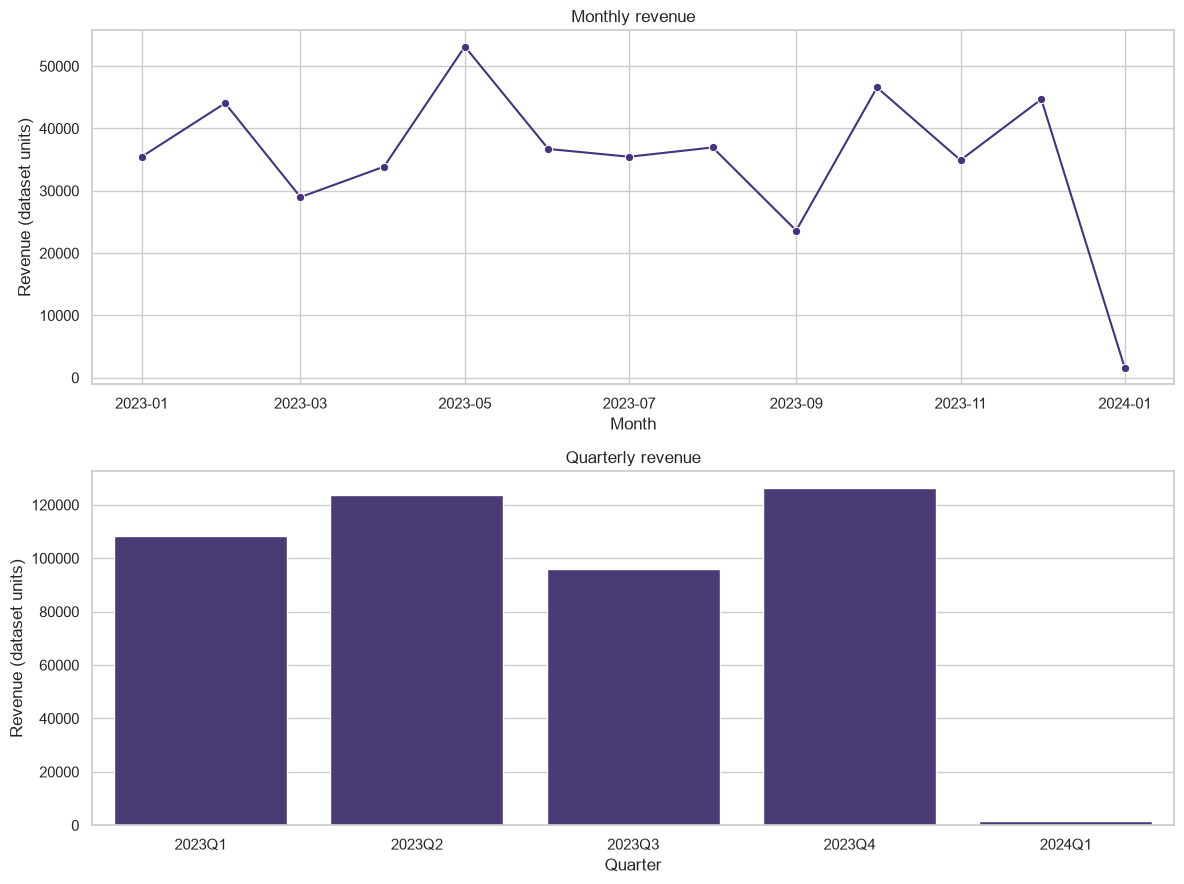

,Month,Total Amount
4,2023-05-01,53150
9,2023-10-01,46580
11,2023-12-01,44690
1,2023-02-01,44060
7,2023-08-01,36960


,Quarter,Total Amount
0,2023Q1,108500
1,2023Q2,123735
2,2023Q3,96045
3,2023Q4,126190
4,2024Q1,1530


In [5]:
monthly = sales.groupby('Month', as_index=False)['Total Amount'].sum()
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
sns.lineplot(data=monthly, x='Month', y='Total Amount', marker='o', ax=axes[0])
axes[0].set(title='Monthly revenue', xlabel='Month', ylabel='Revenue (dataset units)')
quarterly = sales.groupby('Quarter', as_index=False)['Total Amount'].sum()
sns.barplot(data=quarterly, x='Quarter', y='Total Amount', ax=axes[1])
axes[1].set(title='Quarterly revenue', xlabel='Quarter', ylabel='Revenue (dataset units)')
plt.tight_layout()
plt.show()
display(monthly.sort_values('Total Amount', ascending=False).head(5))
display(quarterly)

**Observation:** Check the monthly chart for peaks and troughs rather than assuming a seasonal pattern from one year of data. The source dates span 2023-01-01 to 2024-01-01, so Q1 2024 contains only a small portion of the period and is not comparable to full quarters.

## 5. Customer demographics
The dataset has transaction-level age and gender fields. These charts describe recorded transactions, not necessarily the retailer's full customer population.

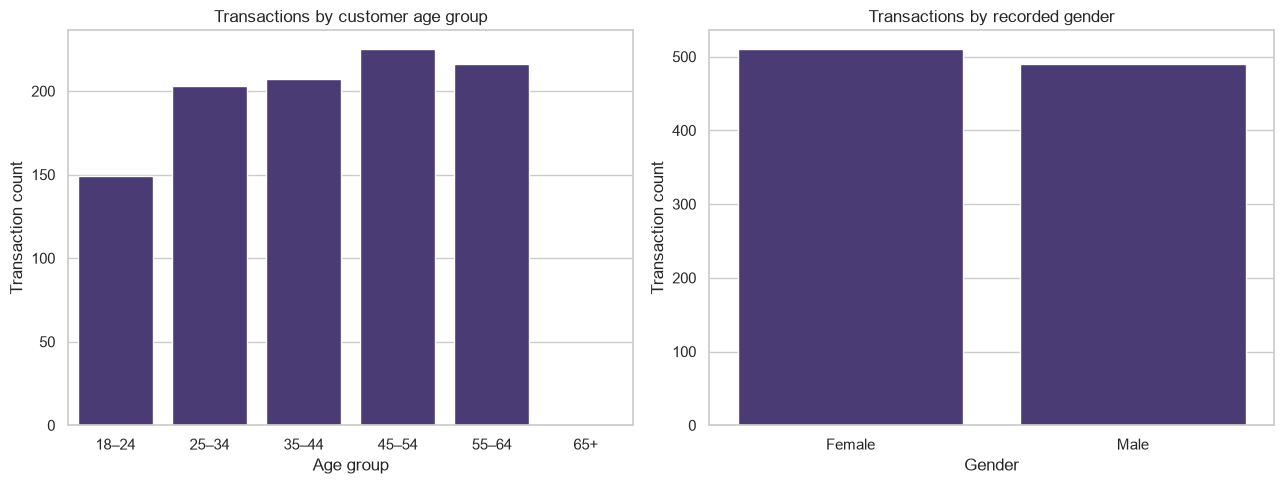

,transactions,revenue,average_transaction
Gender,,,
Female,510,232840,456.55
Male,490,223160,455.43


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=sales, x='Age Group', order=sales['Age Group'].cat.categories, ax=axes[0])
axes[0].set(title='Transactions by customer age group', xlabel='Age group', ylabel='Transaction count')
gender_counts = sales['Gender'].value_counts().rename_axis('Gender').reset_index(name='Transactions')
sns.barplot(data=gender_counts, x='Gender', y='Transactions', ax=axes[1])
axes[1].set(title='Transactions by recorded gender', xlabel='Gender', ylabel='Transaction count')
plt.tight_layout()
plt.show()
display(sales.groupby('Gender', observed=True).agg(
    transactions=('Transaction ID', 'count'), revenue=('Total Amount', 'sum'),
    average_transaction=('Total Amount', 'mean')
).round(2))

## 6. Product and category performance
There is no product-name field, so a true top-10 product ranking cannot be produced from this dataset. Use product category performance instead and note this limitation.

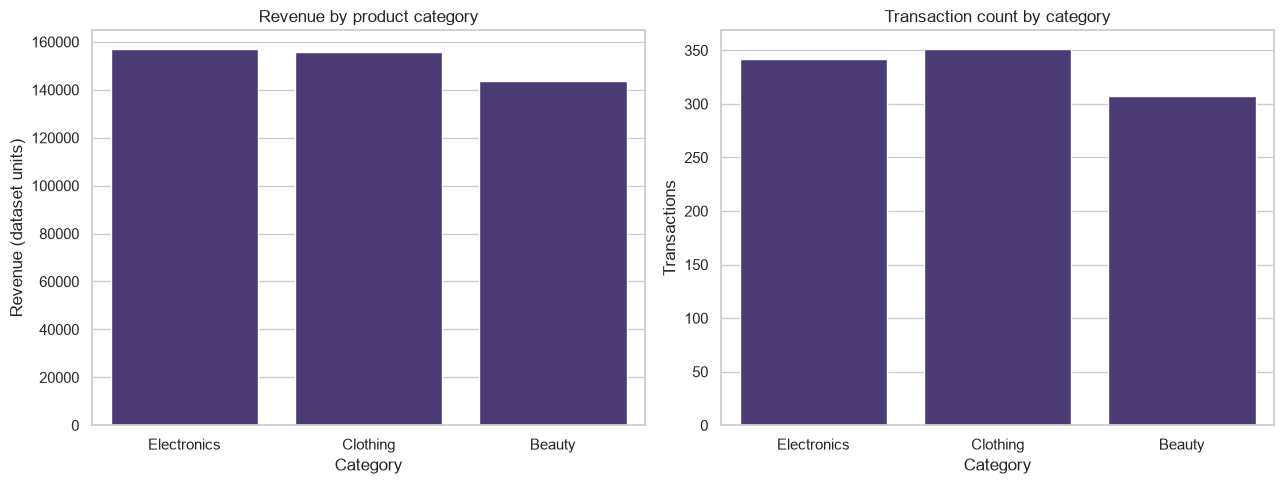

,Product Category,Revenue,Transactions,Average_Transaction
2,Electronics,156905,342,458.79
1,Clothing,155580,351,443.25
0,Beauty,143515,307,467.48


In [7]:
category = sales.groupby('Product Category', as_index=False).agg(
    Revenue=('Total Amount', 'sum'), Transactions=('Transaction ID', 'count'),
    Average_Transaction=('Total Amount', 'mean')
).sort_values('Revenue', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=category, x='Product Category', y='Revenue', ax=axes[0])
axes[0].set(title='Revenue by product category', xlabel='Category', ylabel='Revenue (dataset units)')
sns.barplot(data=category, x='Product Category', y='Transactions', ax=axes[1])
axes[1].set(title='Transaction count by category', xlabel='Category', ylabel='Transactions')
plt.tight_layout()
plt.show()
display(category.round(2))

## 7. Correlation between numerical variables
Correlation measures linear association, not causation. `Total Amount` is mechanically related to quantity and unit price, so those correlations are expected by construction.

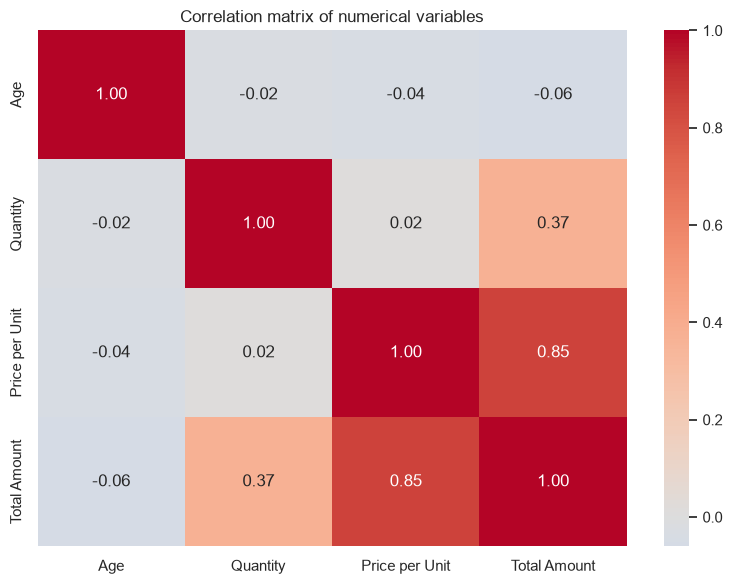

,Age,Quantity,Price per Unit,Total Amount
Age,1.000,-0.024,-0.038,-0.061
Quantity,-0.024,1.000,0.018,0.374
Price per Unit,-0.038,0.018,1.000,0.852
Total Amount,-0.061,0.374,0.852,1.000


In [8]:
corr = sales[numeric_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation matrix of numerical variables')
plt.tight_layout()
plt.show()
corr.round(3)

## 8. Additional visualization: category × gender revenue
This view checks whether category revenue patterns are similar across recorded gender groups. Small differences should not be over-interpreted without a larger representative dataset.

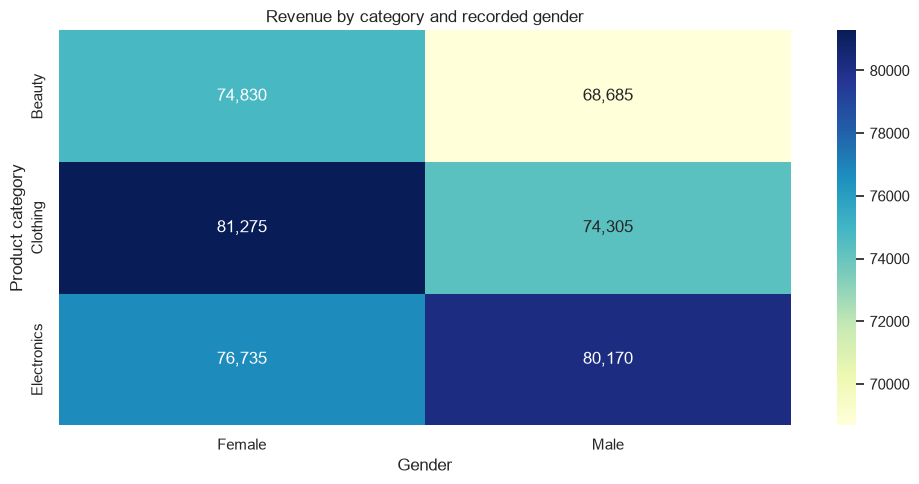

In [9]:
gender_category = sales.pivot_table(index='Product Category', columns='Gender', values='Total Amount', aggfunc='sum', fill_value=0)
sns.heatmap(gender_category, annot=True, fmt=',.0f', cmap='YlGnBu')
plt.title('Revenue by category and recorded gender')
plt.xlabel('Gender')
plt.ylabel('Product category')
plt.tight_layout()
plt.show()

## 9. Key findings

Complete these statements after reviewing the executed charts and tables:
- Highest-revenue month and value: **[fill from monthly summary]**.
- Highest-revenue category and value: **[fill from category table]**.
- Most represented age group: **[fill from demographic chart]**.
- Important caveat: the dataset is small and covers approximately one year; it has no product names, cost/margin, store, or customer repeat-history fields.

## 10. Business recommendations

1. **Plan promotions around observed monthly demand:** validate the peak months against multiple years of data before changing inventory or campaign budgets.
2. **Review category-level stock and marketing:** compare category revenue with margin, returns, and stock availability before prioritizing a category; revenue alone is not profitability.
3. **Improve customer analytics data:** collect reliable product identifiers, costs, channels, and repeat-purchase history to support product ranking, profitability analysis, and customer retention strategies.

## Limitations

- The dataset is educational and small; no statistical inference or causal claim is made.
- Revenue is not profit, and the unit/currency is unspecified.
- The requested top 10 products analysis is not possible because product-level names or IDs are absent.
- The period ends on 2024-01-01; Q1 2024 is incomplete.
- Demographic fields are treated as supplied and are not independently verified.